## GradCam

This notebook demonstrates how to compute and visualize Grad-CAM for a trained model.

We load a trained model and its configuration, run inference on a batch of validation images, and compute Grad-CAM for a selected convolutional layer.

The resulting heatmaps highlight the regions of the image that contribute most to the model’s prediction.


In [8]:
import os

import hydra
from hydra import compose, initialize
import matplotlib.pyplot as plt
import numpy as np 
from omegaconf import OmegaConf
from tqdm import tqdm
from torch.utils.data import DataLoader

from ctl.utils.runners import get_runner_manual
from ctl.utils.grad_cam import get_gradcam
from ctl.utils.general import denormalize
from ctl.utils.configs import setup_config

### Configuration loading

There are two ways to load the configuration:

1. **Default config (from `configs/`)**  
   This is the current config used in `tools/train_torch_dev`.  
   To use it, uncomment the `initialize` and `compose` lines.

2. **Experiment config (from the experiment folder)**  
   This loads the config saved during model training.  
   This option is currently used (the corresponding code is uncommented).

Note:  
If the path to model weights is not specified in the config, it should be set manually.


In [ ]:
# Clear the global Hydra instance before re-initialization
hydra.core.global_hydra.GlobalHydra.instance().clear()

# Load the config specified in configs/config.yaml
# initialize(config_path="../configs/")
# cfg = compose(config_name="config")
# cfg = OmegaConf.to_object(cfg)

# Load the model config from the experiment folder
cfg = setup_config("../experiments/test_run/config.yaml")

# Set the model weights path in the config
cfg["model"]["weights_path"] = "../experiments/test_run/checkpoints/epoch_5.pth"

/tmp/ipykernel_3885215/583935143.py:5: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  initialize(config_path="../configs/")


### Runner initialization

We use a custom runner that handles model, datasets, and hooks.
Here we initialize it in "manual" mode to directly access model and data.


In [11]:
experiment_name = "gradcam"
runner = get_runner_manual(
    cfg,
    experiment_name,
    overwrite=True,
)

runner._local_rank = -1
runner._world_size = -1
runner._run_event("on_experiment_start")

In [12]:
model = runner.model
ds = runner.datasets["valid"].dataset

In [13]:
dl = DataLoader(ds, batch_size=8, shuffle=True)
batch = next(iter(dl))

### Grad-CAM computation

We select the last convolutional layer of EfficientNet-B3 as the target layer.
Grad-CAM will highlight regions that contribute most to the model's prediction.

In [14]:
target_layers = [model.model.features[-1]]  # Conv2dNormActivation at index 8

# x: BCHW torch tensor on same device as model
cams = get_gradcam(
    model=model,
    x=batch[0],
    target_layers=target_layers,
)

Before visualization, we denormalize images to convert them back to a displayable range.

In [15]:
images = denormalize(batch[0], **cfg["transforms"]["augmentations"]["Normalize"])

## Visualization utilities
The visualization function overlays Grad-CAM heatmaps on top of the original images.

Steps:
1. Normalize CAM values
2. Apply a threshold to remove weak activations
3. Convert the CAM to a heatmap
4. Blend the heatmap with the original image


In [16]:
def _stack_images(x):
    if isinstance(x, list):
        x = np.stack(x)
    if x.ndim == 2:      # HW
        x = x[None, ..., None]
    elif x.ndim == 3:
        if x.shape[-1] in (1, 3):  # HWC
            x = x[None]
        else:                      # BHW
            x = x[..., None]
    return x.astype(np.float32)


def _stack_cams(x):
    if isinstance(x, list):
        x = np.stack(x)
    if x.ndim == 2:      # HW
        x = x[None, ..., None]
    elif x.ndim == 3:
        if x.shape[-1] <= 10:  # HWD
            x = x[None]
        else:                  # BHW
            x = x[..., None]
    return x.astype(np.float32)


def visualize_gradcam(images, cams, alpha=0.5, thr=0.3):
    imgs = _stack_images(images)   # (B,H,W,C)
    cams = _stack_cams(cams)       # (B,H,W,D)

    B, H, W, C = imgs.shape
    D = cams.shape[-1]

    fig, axes = plt.subplots(B, 1 + D, figsize=(4*(1+D), 4*B))
    if B == 1:
        axes = axes[None]

    for i in range(B):
        img = imgs[i]

        # make RGB
        if img.shape[-1] == 1:
            img = np.repeat(img, 3, axis=-1)

        # normalize image
        if img.max() > 1:
            img = img / 255.0

        axes[i, 0].imshow(img)
        axes[i, 0].axis("off")

        for d in range(D):
            cam = cams[i, ..., d]

            # normalize CAM
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

            # threshold → remove low activations
            cam = np.clip((cam - thr) / (1 - thr), 0, 1)

            # color map
            heatmap = plt.cm.jet(cam)[..., :3]

            # blend ONLY where CAM > 0
            overlay = img.copy()
            mask = cam > 0

            overlay[mask] = img[mask] * (1 - alpha) + heatmap[mask] * alpha
            overlay = np.clip(overlay, 0, 1)

            axes[i, 1 + d].imshow(overlay)
            axes[i, 1 + d].axis("off")

    plt.tight_layout()
    return fig


We generate and display Grad-CAM visualizations for the current batch.

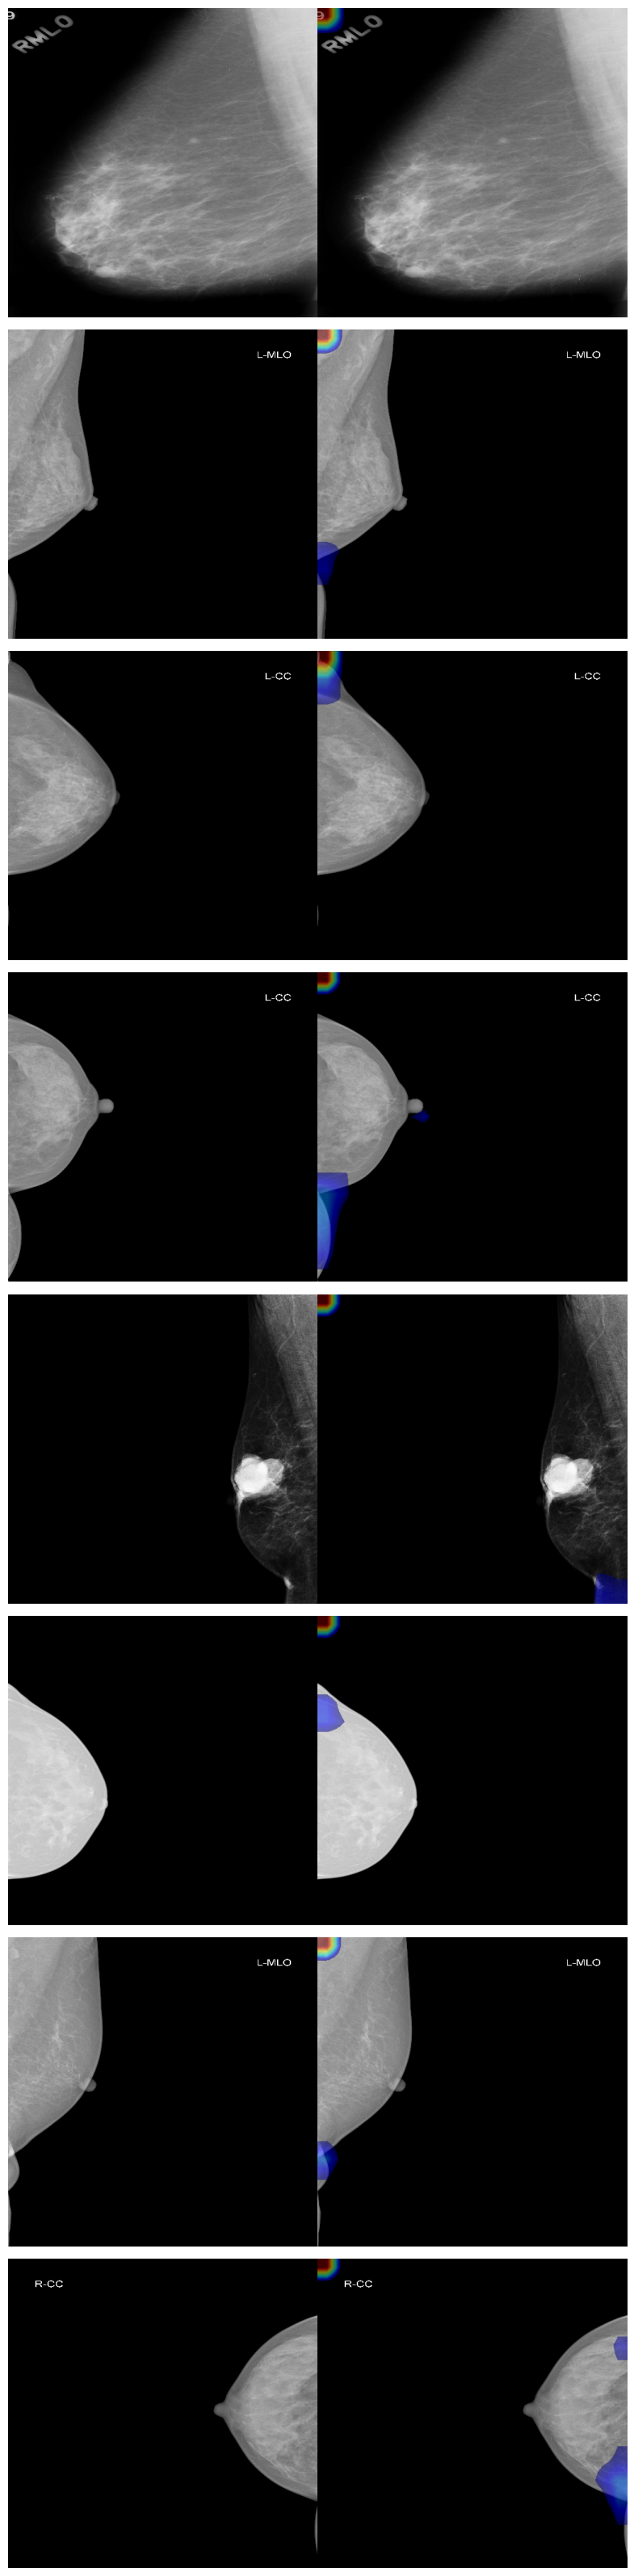

In [17]:
fig = visualize_gradcam(images, cams)
plt.show()